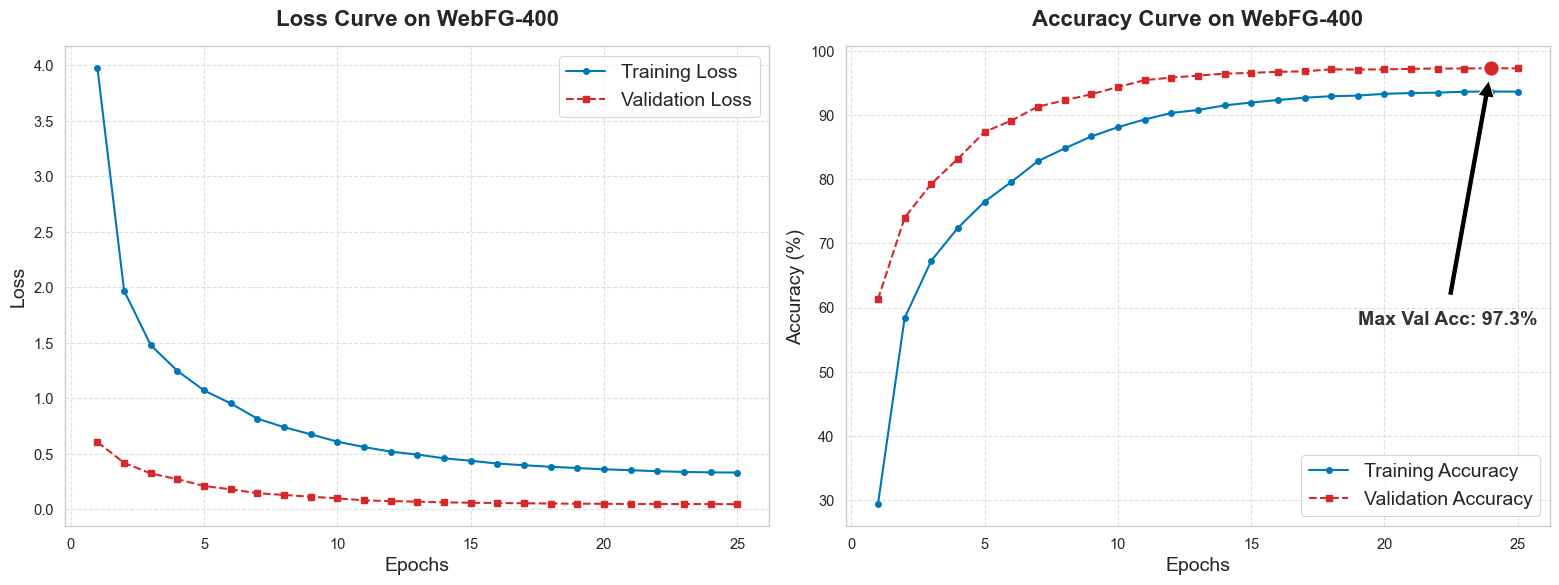

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取数据
# 确保 history.csv 文件在当前目录下
df = pd.read_csv('history.csv')

# 2. 设置绘图风格 (使用 Seaborn 的 whitegrid 风格，美观且适合学术展示)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'sans-serif' # 设置字体

# 3. 创建画布 (1行2列)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 定义颜色 (使用比较专业的配色)
color_train = '#0077b6'  
color_val = '#d62828'  

# --- 绘制 Loss 曲线 (左图) ---
axes[0].plot(df['epoch'], df['train_loss'], label='Training Loss', 
             color=color_train, linewidth=1.5, marker='o', markersize=4)
axes[0].plot(df['epoch'], df['val_loss'], label='Validation Loss', 
             color=color_val, linewidth=1.5, linestyle='--', marker='s', markersize=4)

axes[0].set_title('Loss Curve on WebFG-400', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Epochs', fontsize=14)
axes[0].set_ylabel('Loss', fontsize=14)
axes[0].legend(frameon=True, fontsize=14, loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- 绘制 Accuracy 曲线 (右图) ---
# 注意：csv中的列名包含(%)，这里直接使用原列名
axes[1].plot(df['epoch'], df['train_acc(%)'], label='Training Accuracy', 
             color=color_train, linewidth=1.5, marker='o', markersize=4)
axes[1].plot(df['epoch'], df['val_acc(%)'], label='Validation Accuracy', 
             color=color_val, linewidth=1.5, linestyle='--', marker='s', markersize=4)

max_acc = df['val_acc(%)'].max()
max_epoch = df.loc[df['val_acc(%)'].idxmax(), 'epoch']

# 绘制最高点标记
axes[1].scatter(max_epoch, max_acc, color=color_val, s=150, zorder=5, edgecolor='white', lw=2)
# 添加注释文本
axes[1].annotate(f'Max Val Acc: {max_acc:.1f}%', 
            xy=(max_epoch, max_acc), 
            xytext=(max_epoch - 5, max_acc - 40),
            arrowprops=dict(facecolor='black', shrink=0.05),
            fontsize=14, fontweight='bold', color='#333333')

axes[1].set_title('Accuracy Curve on WebFG-400', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('Epochs', fontsize=14)
axes[1].set_ylabel('Accuracy (%)', fontsize=14)
axes[1].legend(frameon=True, fontsize=14, loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 4. 调整布局并保存/显示
plt.tight_layout()

# 保存图片 (可选)
plt.savefig('webfg400_training_curves.png', dpi=300, bbox_inches='tight')

# 显示图片
plt.show()